In [225]:
# =========================
# PASO 1: Cargar librerías
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [226]:
# ==================================================
# 1. CARGA DE DATOS
# ==================================================

calidad = pd.read_csv("data/raw/calidad_senal_zona_mensual.csv")
df_clientes = pd.read_csv("data/processed/df_clientes.csv")
df_churn = pd.read_csv("data/processed/df_churn.csv")

display(calidad.head())
display(df_clientes.head())
display(df_churn.head())

,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva
0,2023-01-01,Z01,Centro,rural,16625,82.46,4.03,56.17,30.61,3.01,18.51,0
1,2023-02-01,Z01,Centro,rural,16625,82.11,4.31,55.69,30.95,3.06,19.61,0
2,2023-03-01,Z01,Centro,rural,16625,82.19,4.56,55.45,31.05,2.96,16.99,0
3,2023-04-01,Z01,Centro,rural,16625,81.90,4.69,55.72,30.43,3.00,20.81,0
4,2023-05-01,Z01,Centro,rural,16625,81.86,5.38,55.38,30.47,3.01,18.61,0


,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,churn
0,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,0
1,C000002,Z15,Oeste,suburbana,62939,54.0,M,Casado/a,2,Premium,Gama media,4609.0,35.0,1,0
2,C000003,Z27,Norte,suburbana,42704,54.0,M,Casado/a,3,Prepago,Gama baja,1836.0,11.0,0,1
3,C000004,Z22,Este,suburbana,53534,34.0,M,Soltero/a,1,Prepago,Gama media,2318.0,13.0,0,0
4,C000005,Z04,Centro,suburbana,55457,46.0,F,Soltero/a,2,Contrato,Gama media,2184.0,21.0,0,0


,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


In [227]:
# ==================================================
# 2. ESTRUCTURA Y TIPOS
# ==================================================

print("CALIDAD")
calidad.info()

print("\nCLIENTES")
df_clientes.info()

print("\nCHURN")
df_churn.info()

CALIDAD
<class 'pandas.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fecha                  1096 non-null   str    
 1   zona_id                1096 non-null   str    
 2   region                 1096 non-null   str    
 3   tipo_zona              1096 non-null   str    
 4   poblacion_zona         1096 non-null   int64  
 5   cobertura_4g_pct       1064 non-null   float64
 6   cobertura_5g_pct       1064 non-null   float64
 7   latencia_ms            1063 non-null   float64
 8   velocidad_media_mbps   1096 non-null   float64
 9   tasa_cortes_pct        1096 non-null   float64
 10  indice_calidad_global  1096 non-null   float64
 11  incidencia_masiva      1096 non-null   int64  
dtypes: float64(6), int64(2), str(4)
memory usage: 102.9 KB

CLIENTES
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 

In [228]:
# ==================================================
# 3. QUALITY CHECK INICIAL
# ==================================================

print("NULOS CALIDAD")
print(calidad.isnull().sum())

print("\nNULOS CLIENTES")
print(df_clientes.isnull().sum())

print("\nNULOS CHURN")
print(df_churn.isnull().sum())

print("\nDUPLICADOS")
print("Calidad:", calidad.duplicated().sum())
print("Clientes:", df_clientes.duplicated().sum())
print("Churn:", df_churn.duplicated().sum())

print("\nIDS DUPLICADOS")
print("cliente_id clientes:", df_clientes["cliente_id"].duplicated().sum())
print("cliente_id churn:", df_churn["cliente_id"].duplicated().sum())

print("\nVALORES CHURN")
print(df_churn["churn"].value_counts(dropna=False))

NULOS CALIDAD
fecha                     0
zona_id                   0
region                    0
tipo_zona                 0
poblacion_zona            0
cobertura_4g_pct         32
cobertura_5g_pct         32
latencia_ms              33
velocidad_media_mbps      0
tasa_cortes_pct           0
indice_calidad_global     0
incidencia_masiva         0
dtype: int64

NULOS CLIENTES
cliente_id          0
zona_id             0
region              0
tipo_zona           0
poblacion_zona      0
edad                0
sexo                0
estado_civil        0
num_lineas          0
tipo_plan           0
tipo_dispositivo    0
ingreso_estimado    0
antiguedad_meses    0
descuento_activo    0
churn               0
dtype: int64

NULOS CHURN
cliente_id    0
fecha         0
churn         0
dtype: int64

DUPLICADOS
Calidad: 16
Clientes: 0
Churn: 0

IDS DUPLICADOS
cliente_id clientes: 0
cliente_id churn: 311987

VALORES CHURN
churn
0    319987
1      2000
Name: count, dtype: int64


In [229]:
# ==================================================
# 4. LIMPIEZA BÁSICA DE CALIDAD
# ==================================================

calidad = calidad.drop_duplicates()

# Rellenar nulos de calidad con la media
columnas_num_calidad = calidad.select_dtypes(include=["int64", "float64"]).columns

for col in columnas_num_calidad:
    calidad[col] = calidad[col].fillna(calidad[col].mean())

print("Nulos después de limpiar calidad:")
print(calidad.isnull().sum())

print("\nDuplicados después de limpiar calidad:")
print(calidad.duplicated().sum())

Nulos después de limpiar calidad:
fecha                    0
zona_id                  0
region                   0
tipo_zona                0
poblacion_zona           0
cobertura_4g_pct         0
cobertura_5g_pct         0
latencia_ms              0
velocidad_media_mbps     0
tasa_cortes_pct          0
indice_calidad_global    0
incidencia_masiva        0
dtype: int64

Duplicados después de limpiar calidad:
0


In [230]:
# ==================================================
# 5. LIMPIAR VALORES IMPOSIBLES
# ==================================================

print("Velocidades negativas antes:")
print((calidad["velocidad_media_mbps"] < 0).sum())

media_velocidad = calidad.loc[
    calidad["velocidad_media_mbps"] >= 0,
    "velocidad_media_mbps"
].mean()

calidad.loc[
    calidad["velocidad_media_mbps"] < 0,
    "velocidad_media_mbps"
] = media_velocidad

print("Velocidades negativas después:")
print((calidad["velocidad_media_mbps"] < 0).sum())

Velocidades negativas antes:
16
Velocidades negativas después:
0


In [231]:
# ==================================================
# 6. QUALITY CHECK DE RANGOS
# ==================================================

columnas_calidad = [
    "cobertura_4g_pct",
    "cobertura_5g_pct",
    "latencia_ms",
    "velocidad_media_mbps",
    "tasa_cortes_pct",
    "indice_calidad_global",
    "incidencia_masiva"
]

for col in columnas_calidad:
    print("\n", col)
    print("Mínimo:", calidad[col].min())
    print("Máximo:", calidad[col].max())
    print("Media:", calidad[col].mean())


 cobertura_4g_pct
Mínimo: 79.23
Máximo: 95.39
Media: 87.75119274809161

 cobertura_5g_pct
Mínimo: 2.77
Máximo: 71.13
Media: 25.224093511450384

 latencia_ms
Mínimo: 22.9
Máximo: 559.9
Media: 47.72731870229008

 velocidad_media_mbps
Mínimo: 11.37
Máximo: 97.34
Media: 56.61325187969925

 tasa_cortes_pct
Mínimo: 0.42
Máximo: 8.4
Media: 2.061490740740741

 indice_calidad_global
Mínimo: 13.94
Máximo: 65.48
Media: 35.085351851851854

 incidencia_masiva
Mínimo: 0
Máximo: 1
Media: 0.004629629629629629


In [232]:
# ==================================================
# 8. CONSTRUCCIÓN BASE ANALÍTICA
# CLIENTES + CHURN
# ==================================================

df = df_clientes.merge(
    df_churn,
    on="cliente_id",
    how="left",
    suffixes=("", "_churn")
)

display(df.head())
print(df.shape)

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,churn,fecha,churn_churn
0,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,0,2023-01-01,0
1,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,0,2023-02-01,0
2,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,0,2023-03-01,0
3,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,0,2023-04-01,0
4,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,0,2023-05-01,0


(321987, 17)


In [233]:
# =========================================================
# 4. ELIMINAR DUPLICADOS
# =========================================================

df = df.drop_duplicates(subset=["cliente_id"], keep="first")

df = df.reset_index(drop=True)

print(df.shape)

# =========================================================
# 5. CHECKEO FINAL
# =========================================================

print("Duplicados exactos:")
print(df.duplicated().sum())

print("Clientes repetidos:")
print(df["cliente_id"].duplicated().sum())

print("Nulos:")
print(df.isnull().sum().sum())

(10000, 17)
Duplicados exactos:
0
Clientes repetidos:
0
Nulos:
0


In [234]:
# ==================================================
# 9. ARREGLAR CHURN SI SALE DUPLICADO
# ==================================================

# Si df_clientes ya tenía churn, usamos ese y quitamos churn_churn
if "churn_churn" in df.columns:
    df = df.drop(columns=["churn_churn"])

# Si aparece fecha del churn, la quitamos para este enfoque
if "fecha" in df.columns:
    df = df.drop(columns=["fecha"])

display(df.head())
print(df.columns)

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,churn
0,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0,0
1,C000002,Z15,Oeste,suburbana,62939,54.0,M,Casado/a,2,Premium,Gama media,4609.0,35.0,1,0
2,C000003,Z27,Norte,suburbana,42704,54.0,M,Casado/a,3,Prepago,Gama baja,1836.0,11.0,0,1
3,C000004,Z22,Este,suburbana,53534,34.0,M,Soltero/a,1,Prepago,Gama media,2318.0,13.0,0,0
4,C000005,Z04,Centro,suburbana,55457,46.0,F,Soltero/a,2,Contrato,Gama media,2184.0,21.0,0,0


Index(['cliente_id', 'zona_id', 'region', 'tipo_zona', 'poblacion_zona',
       'edad', 'sexo', 'estado_civil', 'num_lineas', 'tipo_plan',
       'tipo_dispositivo', 'ingreso_estimado', 'antiguedad_meses',
       'descuento_activo', 'churn'],
      dtype='str')


In [235]:
# ==================================================
# 10. AGREGAR CALIDAD POR ZONA
# ==================================================

calidad_zona = calidad.groupby("zona_id").agg({
    "cobertura_4g_pct": "mean",
    "cobertura_5g_pct": "mean",
    "latencia_ms": "mean",
    "velocidad_media_mbps": "mean",
    "tasa_cortes_pct": "mean",
    "indice_calidad_global": "mean",
    "incidencia_masiva": "mean"
}).reset_index()

display(calidad_zona.head())

,zona_id,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva
0,Z01,82.043889,13.698611,52.648814,37.478146,2.914722,23.032500,0.0
1,Z02,90.061944,26.935000,38.190684,62.470278,1.598333,38.535556,0.0
2,Z03,82.461211,13.506894,66.661240,36.220833,3.027778,22.442500,0.0
3,Z04,90.070311,27.102614,46.594370,62.655924,1.472778,39.168056,0.0
4,Z05,94.084722,41.923447,29.078889,84.677222,0.890000,50.811389,0.0


In [236]:
# ==================================================
# 11. UNIÓN FINAL CLIENTES + CHURN + CALIDAD
# ==================================================

df = df.merge(calidad_zona, on="zona_id", how="left")

display(df.head())
print(df.shape)

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,...,antiguedad_meses,descuento_activo,churn,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva
0,C000001,Z26,Oeste,urbana_premium,107159,18.0,M,Soltero/a,2,Prepago,...,72.0,0,0,93.975589,42.586780,30.491795,82.897313,0.872500,51.116667,0.000000
1,C000002,Z15,Oeste,suburbana,62939,54.0,M,Casado/a,2,Premium,...,35.0,1,0,89.757255,27.254836,46.204167,61.296479,1.605278,38.333611,0.000000
2,C000003,Z27,Norte,suburbana,42704,54.0,M,Casado/a,3,Prepago,...,11.0,0,1,89.853333,26.311339,40.001111,60.337222,2.085833,38.674722,0.027778
3,C000004,Z22,Este,suburbana,53534,34.0,M,Soltero/a,1,Prepago,...,13.0,0,0,89.874511,26.624167,37.563056,61.908792,1.568611,38.565000,0.000000
4,C000005,Z04,Centro,suburbana,55457,46.0,F,Soltero/a,2,Contrato,...,21.0,0,0,90.070311,27.102614,46.594370,62.655924,1.472778,39.168056,0.000000


(10000, 22)


In [237]:
# ==================================================
# 12. QUALITY CHECK FINAL
# ==================================================

print("Nulos finales:")
print(df.isnull().sum())

print("\nDuplicados finales:")
print(df.duplicated().sum())

print("\nTamaño final:")
print(df.shape)

print("\nValores churn:")
print(df["churn"].value_counts(dropna=False))

Nulos finales:
cliente_id                 0
zona_id                    0
region                     0
tipo_zona                  0
poblacion_zona             0
edad                       0
sexo                       0
estado_civil               0
num_lineas                 0
tipo_plan                  0
tipo_dispositivo           0
ingreso_estimado           0
antiguedad_meses           0
descuento_activo           0
churn                      0
cobertura_4g_pct         150
cobertura_5g_pct         150
latencia_ms              150
velocidad_media_mbps     150
tasa_cortes_pct          150
indice_calidad_global    150
incidencia_masiva        150
dtype: int64

Duplicados finales:
0

Tamaño final:
(10000, 22)

Valores churn:
churn
0    8000
1    2000
Name: count, dtype: int64


In [238]:
# Si quedan nulos numéricos después del merge
columnas_num = df.select_dtypes(include=["int64", "float64"]).columns

for col in columnas_num:
    df[col] = df[col].fillna(df[col].mean())

print("Total nulos finales:")
print(df.isnull().sum().sum())

Total nulos finales:
0


churn
0    42.433889
1    38.666040
Name: indice_calidad_global, dtype: float64


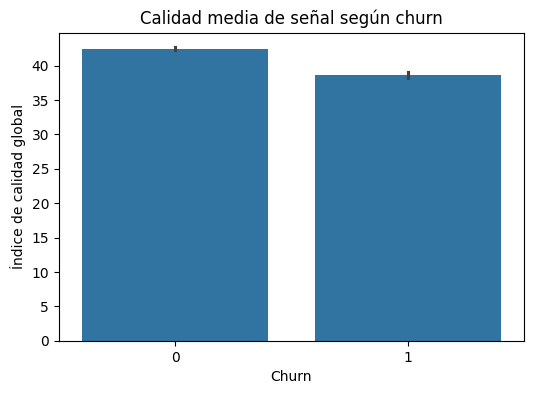

In [239]:
# ==================================================
# 13. HIPÓTESIS 1
# Las zonas con peor calidad global presentan mayor churn
# ==================================================

print(df.groupby("churn")["indice_calidad_global"].mean())

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="churn", y="indice_calidad_global")
plt.title("Calidad media de señal según churn")
plt.xlabel("Churn")
plt.ylabel("Índice de calidad global")
plt.show()

churn
0    1.492735
1    1.770293
Name: tasa_cortes_pct, dtype: float64


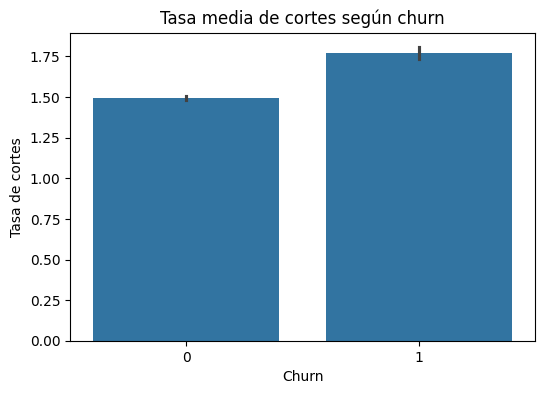

In [240]:
# ==================================================
# 14. HIPÓTESIS 2
# Los clientes de zonas con más cortes tienen mayor churn
# ==================================================

print(df.groupby("churn")["tasa_cortes_pct"].mean())

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="churn", y="tasa_cortes_pct")
plt.title("Tasa media de cortes según churn")
plt.xlabel("Churn")
plt.ylabel("Tasa de cortes")
plt.show()

churn
0    40.246242
1    44.076997
Name: latencia_ms, dtype: float64


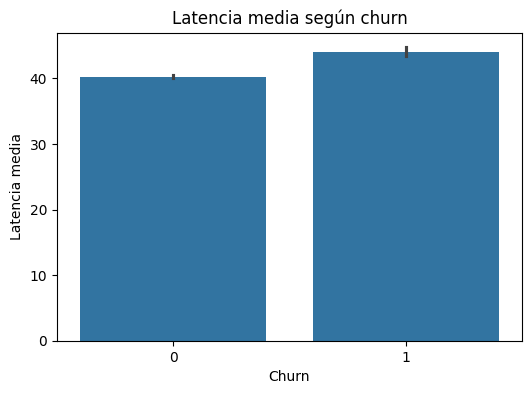

In [241]:
# ==================================================
# 15. HIPÓTESIS 3
# Una mayor latencia se relaciona con más churn
# ==================================================

print(df.groupby("churn")["latencia_ms"].mean())

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="churn", y="latencia_ms")
plt.title("Latencia media según churn")
plt.xlabel("Churn")
plt.ylabel("Latencia media")
plt.show()

churn
0    68.998063
1    62.601094
Name: velocidad_media_mbps, dtype: float64


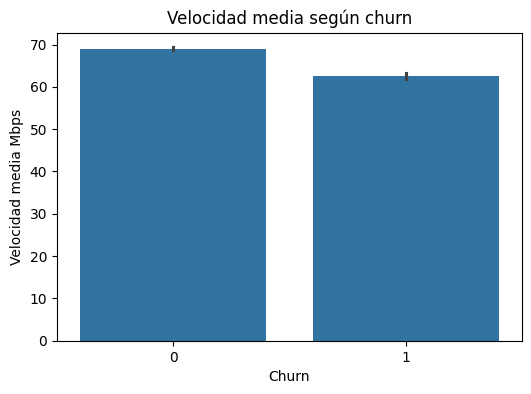

In [242]:
# ==================================================
# 16. HIPÓTESIS 4
# Una menor velocidad media puede relacionarse con mayor churn
# ==================================================

print(df.groupby("churn")["velocidad_media_mbps"].mean())

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="churn", y="velocidad_media_mbps")
plt.title("Velocidad media según churn")
plt.xlabel("Churn")
plt.ylabel("Velocidad media Mbps")
plt.show()

churn
0    0.004211
1    0.004210
Name: incidencia_masiva, dtype: float64


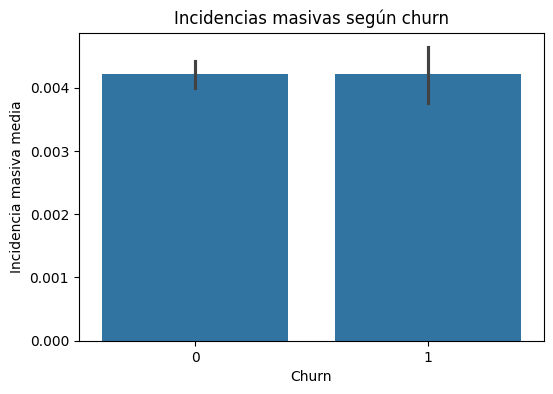

In [243]:
# ==================================================
# 17. HIPÓTESIS 5
# Las zonas con más incidencias masivas presentan más churn
# ==================================================

print(df.groupby("churn")["incidencia_masiva"].mean())

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="churn", y="incidencia_masiva")
plt.title("Incidencias masivas según churn")
plt.xlabel("Churn")
plt.ylabel("Incidencia masiva media")
plt.show()

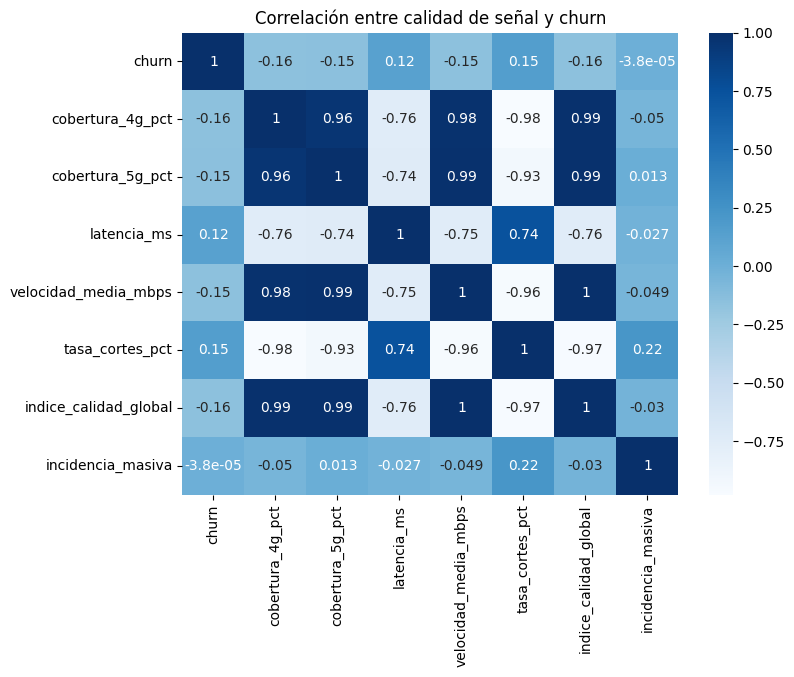

In [244]:
# ==================================================
# 19. CORRELACIÓN ENTRE CALIDAD Y CHURN
# ==================================================

columnas_corr = [
    "churn",
    "cobertura_4g_pct",
    "cobertura_5g_pct",
    "latencia_ms",
    "velocidad_media_mbps",
    "tasa_cortes_pct",
    "indice_calidad_global",
    "incidencia_masiva"
]

corr = df[columnas_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlación entre calidad de señal y churn")
plt.show()





H1: Las zonas con menor índice de calidad global presentan mayor churn.

H2: Los clientes ubicados en zonas con mayor tasa de cortes tienen más probabilidad de abandonar.

H3: Una mayor latencia media puede estar asociada con un aumento del churn.

H4: Las zonas con menor velocidad media pueden presentar una mayor tasa de abandono.

H5: Las zonas con más incidencias masivas pueden concentrar más clientes con churn.
""")

En conclusión, el análisis mostró que la calidad de red tiene relación con el churn de los clientes. Las zonas con peor cobertura, mayor latencia y más cortes de señal presentan mayores tasas de abandono. Además, se observó que un deterioro progresivo en la calidad del servicio puede actuar como una señal previa al churn. El estudio también permitió identificar regiones con mayor riesgo operativo y confirmó que las variables relacionadas con la calidad de señal aportan información útil para modelos predictivos de churn. En general, los resultados sugieren que mejorar la estabilidad y cobertura de la red podría ayudar a reducir la pérdida de clientes y mejorar la experiencia del usuario.